# Entrenamiento de modelos de clasificación

## 1. Importando librerías

In [45]:
# Importando librerías
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

## 2. Cargando el dataset y visualizando los datos

In [46]:
# Cargando el dataset
df = pd.read_csv("../dataset/bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,term_deposit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [47]:
# Comprobando si hay nulos
print(df.isnull().sum())

age             0
job             0
marital         0
education       0
default         0
balance         0
housing         0
loan            0
contact         0
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome        0
term_deposit    0
dtype: int64


In [48]:
# Visualizando los datos estadísticos del dataset
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [49]:
# Viendo las variables y sus tipos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           45211 non-null  int64 
 1   job           45211 non-null  object
 2   marital       45211 non-null  object
 3   education     45211 non-null  object
 4   default       45211 non-null  object
 5   balance       45211 non-null  int64 
 6   housing       45211 non-null  object
 7   loan          45211 non-null  object
 8   contact       45211 non-null  object
 9   day           45211 non-null  int64 
 10  month         45211 non-null  object
 11  duration      45211 non-null  int64 
 12  campaign      45211 non-null  int64 
 13  pdays         45211 non-null  int64 
 14  previous      45211 non-null  int64 
 15  poutcome      45211 non-null  object
 16  term_deposit  45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### Análisis del desbalance de clases

In [50]:
class_counts = df["term_deposit"].value_counts()
class_percentages = df["term_deposit"].value_counts(normalize=True) * 100

print("Conteo de clases:", class_counts)
print("Porcentaje de clases:", class_percentages)

Conteo de clases: term_deposit
no     39922
yes     5289
Name: count, dtype: int64
Porcentaje de clases: term_deposit
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


# 3. Preprocesamiento de datos

In [ ]:
# Preparando la variable objetivo
df["term_deposit"] = df["term_deposit"].replace({"no": 0, "yes": 1})

df_procesado = pd.get_dummies(df, drop_first=True, dtype=int)
df_procesado

/tmp/ipykernel_48837/3776644882.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["term_deposit"] = df["term_deposit"].replace({"no": 0, "yes": 1})


,age,balance,day,duration,campaign,pdays,previous,term_deposit,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
1,44,29,5,151,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,33,2,5,76,1,-1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
3,47,1506,5,92,1,-1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
4,33,1,5,198,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,825,17,977,3,-1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
45207,71,1729,17,456,2,-1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
45208,72,5715,17,1127,5,184,3,1,0,0,...,0,0,0,0,1,0,0,0,1,0
45209,57,668,17,508,4,-1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1


## 4. División de los datos en entrenamiento y prueba

En esta sección, nos encargamos de dividir nuestro dataset en conjuntos de entrenamiento y prueba. Aquí, he de recalcar que al estar usando un dataset con clases desbalanceadas, es importante usar la opción `stratify` para asegurar que ambas clases estén representadas proporcionalmente en ambos conjuntos.

In [52]:
# Definiendo X e y
X = df_procesado.drop(columns=["term_deposit", "duration"])
y = df_procesado["term_deposit"]

# Haciendo la división de los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado de los datos númericos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 5. Entrenando el modelo de Regresión Logística

En este apartado se entrena un primer modelo base sin aplicar pesos de clase.

In [53]:
# Definiendo el modelo de Regresión Logística
regresion_logistica = LogisticRegression(C=0.5, n_jobs=-1, random_state=42)

# Entrenando el modelo
regresion_logistica.fit(X_train, y_train)

# Haciendo predicciones con el modelo entrenado
y_pred_regresion = regresion_logistica.predict(X_test)

# Haciendo primera valoración con accuracy
accuracy_regresion = accuracy_score(y_test, y_pred_regresion)
print("Accuracy del modelo de Regresión Logística:", accuracy_regresion)

Accuracy del modelo de Regresión Logística: 0.8935087913303107


## 6. Entrenando el modelo de SVM

En este apartado se entrena un modelo SVM para comparar su comportamiento frente al resto.

In [54]:
# Definiendo el modelo de SVM
svm = SVC(kernel="rbf", C=1, gamma="scale", random_state=42)

# Entrenando el modelo de SVM
svm.fit(X_train, y_train)

# Haciendo predicciones con el modelo de SVM
y_pred_svm = svm.predict(X_test)

# Haciendo primera valoración con accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy del modelo de SVM:", accuracy_svm)

Accuracy del modelo de SVM: 0.8941722879575362


## 7. Entrenando el modelo de Random Forest

En este apartado se entrena Random Forest como modelo basado en múltiples árboles de decisión.

In [55]:
# Definiendo el modelo de RandomForest
random_forest = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=-1, bootstrap=True)

# Entrenando el modelo de RandomForest
random_forest.fit(X_train, y_train)

# Haciendo predicciones con el modelo de RandomForest
y_pred_random_forest = random_forest.predict(X_test)

# Haciendo primera valoración con accuracy
accuracy_random_forest = accuracy_score(y_test, y_pred_random_forest)
print("Accuracy del modelo de Random Forest:", accuracy_random_forest)

Accuracy del modelo de Random Forest: 0.8946146190423532


## 8. Evaluación intensiva de los modelos sin class_weight

En este apartado se visualizan las matrices de confusión de los modelos sin tratamiento directo del desbalance.

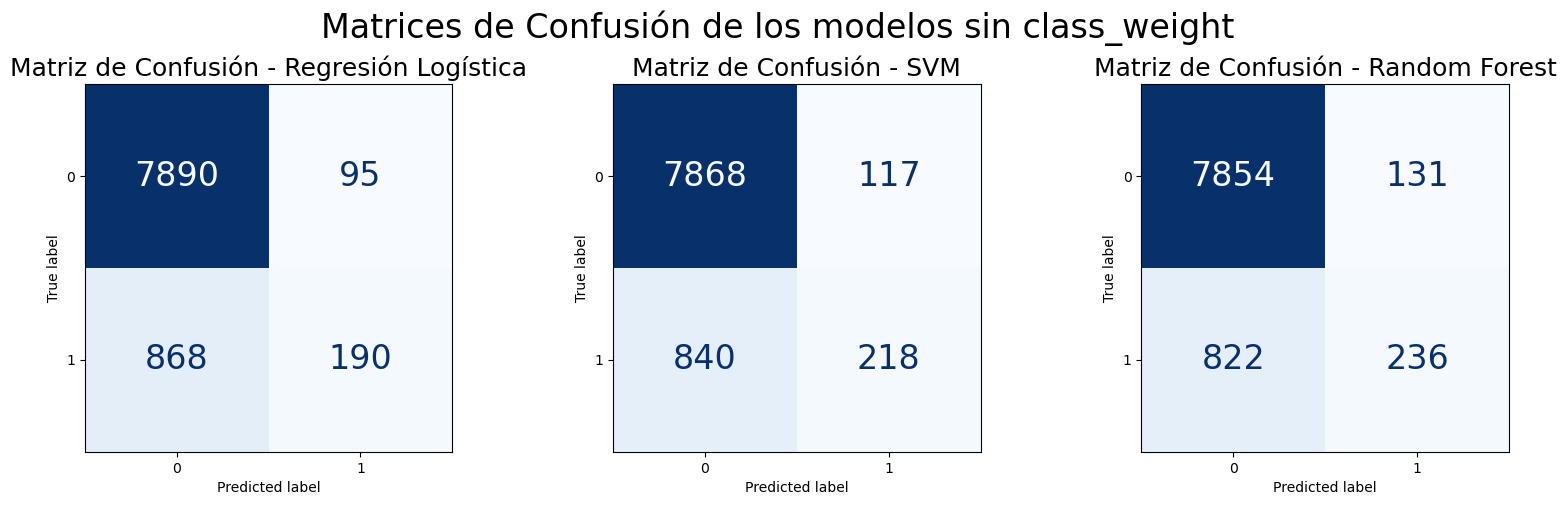

Regresión Logística
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.67      0.18      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.87      9043

SVM
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.65      0.21      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043

Random Forest
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.64      0.22      0.33      1058

    accuracy                           0.89      9043
   macro avg       0.77      0.60      0.64      9043
weighted avg       0.87      0.89   

In [56]:
# Mostrando las matrices de confusión de cada modelo, explicando los resultados y comparándolos entre sí
cm_regresion = confusion_matrix(y_test, y_pred_regresion)
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_random_forest = confusion_matrix(y_test, y_pred_random_forest)

disp_regresion = ConfusionMatrixDisplay(confusion_matrix=cm_regresion, display_labels=regresion_logistica.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm.classes_)
disp_random_forest = ConfusionMatrixDisplay(confusion_matrix=cm_random_forest, display_labels=random_forest.classes_)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
disp_regresion.plot(ax=axes[0], cmap="Blues", colorbar=False, text_kw={"fontsize":24})
disp_svm.plot(ax=axes[1], cmap="Blues", colorbar=False, text_kw={"fontsize":24})
disp_random_forest.plot(ax=axes[2], cmap="Blues", colorbar=False, text_kw={"fontsize":24})
axes[0].set_title("Matriz de Confusión - Regresión Logística", fontsize=18)
axes[1].set_title("Matriz de Confusión - SVM", fontsize=18)
axes[2].set_title("Matriz de Confusión - Random Forest", fontsize=18)

# Poniendo el titulo de la gráfica
plt.suptitle("Matrices de Confusión de los modelos sin class_weight", fontsize=24)
plt.tight_layout()
plt.show()

# Mostramos también precision, recall y F1-score de los modelos con class_weight, para comprobar si el balanceo mejora la detección de la clase minoritaria
print("Regresión Logística")
print(classification_report(y_test, y_pred_regresion))

print("SVM")
print(classification_report(y_test, y_pred_svm))

print("Random Forest")
print(classification_report(y_test, y_pred_random_forest))


## 9. Entrenando modelo de Regresión Logística con class_weight

En este apartado se entrena Regresión Logística dando más peso a la clase minoritaria.

In [57]:
# Definiendo el modelo de Regresión Logística
regresion_logistica_class = LogisticRegression(C=0.5, n_jobs=-1, random_state=42, class_weight="balanced")

# Entrenando el modelo
regresion_logistica_class.fit(X_train, y_train)

# Haciendo predicciones con el modelo entrenado
y_pred_regresion_class = regresion_logistica_class.predict(X_test)

# Haciendo primera valoración con accuracy
accuracy_regresion_class = accuracy_score(y_test, y_pred_regresion_class)
print("Accuracy del modelo de Regresión Logística:", accuracy_regresion_class)
print("Classification Report del modelo de Regresión Logística:")
print(classification_report(y_test, y_pred_regresion_class))

Accuracy del modelo de Regresión Logística: 0.7557226584098198
Classification Report del modelo de Regresión Logística:
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      7985
           1       0.27      0.62      0.37      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043



## 10. Entrenando modelo de SVM con class_weight

En este apartado se entrena SVM con pesos de clase para penalizar más los errores sobre la clase minoritaria.

In [58]:
# Definiendo el modelo de SVM
svm_class = SVC(kernel="rbf", C=1, gamma="scale", random_state=42, class_weight="balanced")

# Entrenando el modelo de SVM
svm_class.fit(X_train, y_train)

# Haciendo predicciones con el modelo de SVM
y_pred_svm_class = svm_class.predict(X_test)

# Haciendo primera valoración con accuracy
accuracy_svm_class = accuracy_score(y_test, y_pred_svm_class)
print("Accuracy del modelo de SVM:", accuracy_svm_class)

Accuracy del modelo de SVM: 0.8281543735486011


## 11. Entrenando modelo de Random Forest con class_weight

En este apartado se entrena Random Forest con pesos de clase para comparar si mejora la detección de la clase positiva.

In [59]:
# Definiendo el modelo de RandomForest
random_forest_class = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=-1, bootstrap=True, class_weight="balanced")

# Entrenando el modelo de RandomForest
random_forest_class.fit(X_train, y_train)

# Haciendo predicciones con el modelo de RandomForest
y_pred_random_forest_class = random_forest_class.predict(X_test)

# Haciendo primera valoración con accuracy
accuracy_random_forest_class = accuracy_score(y_test, y_pred_random_forest_class)
print("Accuracy del modelo de Random Forest:", accuracy_random_forest_class)


Accuracy del modelo de Random Forest: 0.8946146190423532


## 12. Evaluación intensiva de los modelos con class_weight

En este apartado se comparan las matrices de confusión de los modelos entrenados con pesos de clase.

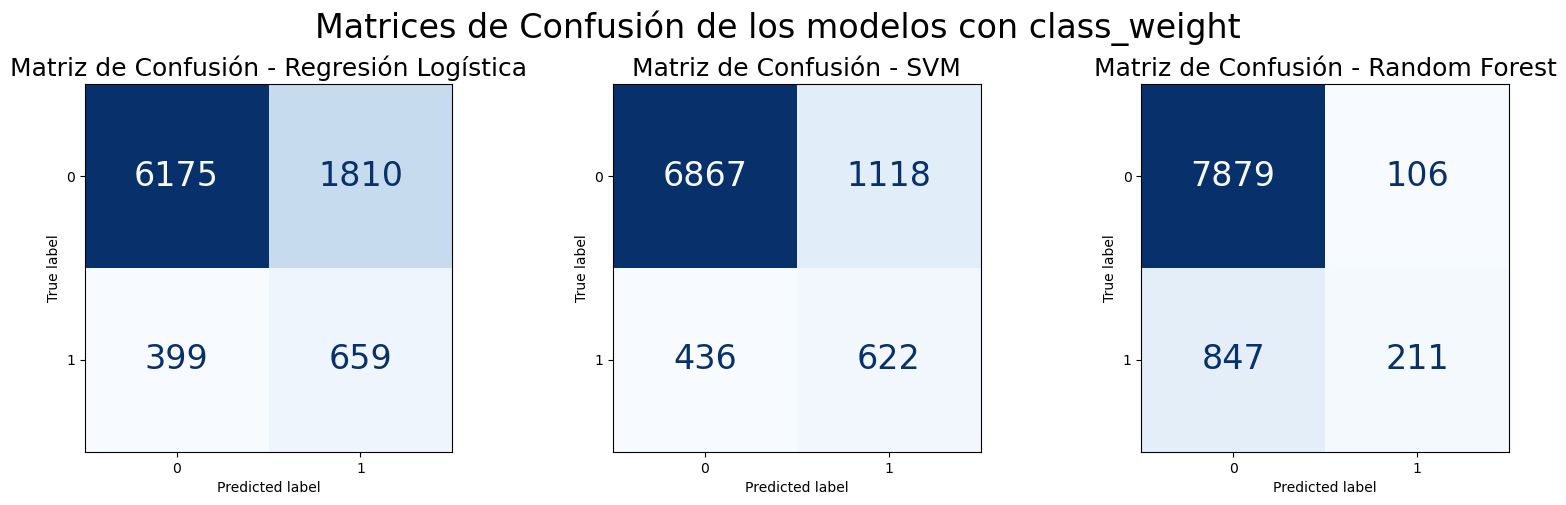

Regresión Logística con class_weight
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      7985
           1       0.27      0.62      0.37      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043

SVM con class_weight
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      7985
           1       0.36      0.59      0.44      1058

    accuracy                           0.83      9043
   macro avg       0.65      0.72      0.67      9043
weighted avg       0.87      0.83      0.85      9043

Random Forest con class_weight
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.67      0.20      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.59      

In [60]:
# Mostrando las matrices de confusión de cada modelo, explicando los resultados y comparándolos entre sí
cm_regresion_class = confusion_matrix(y_test, y_pred_regresion_class)
cm_svm_class = confusion_matrix(y_test, y_pred_svm_class)
cm_random_forest_class = confusion_matrix(y_test, y_pred_random_forest_class)

disp_regresion_class = ConfusionMatrixDisplay(confusion_matrix=cm_regresion_class, display_labels=regresion_logistica_class.classes_)
disp_svm_class = ConfusionMatrixDisplay(confusion_matrix=cm_svm_class, display_labels=svm_class.classes_)
disp_random_forest_class = ConfusionMatrixDisplay(confusion_matrix=cm_random_forest_class, display_labels=random_forest_class.classes_)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
disp_regresion_class.plot(ax=axes[0], cmap="Blues", colorbar=False, text_kw={"fontsize":24})
disp_svm_class.plot(ax=axes[1], cmap="Blues", colorbar=False, text_kw={"fontsize":24})
disp_random_forest_class.plot(ax=axes[2], cmap="Blues", colorbar=False, text_kw={"fontsize":24})
axes[0].set_title("Matriz de Confusión - Regresión Logística", fontsize=18)
axes[1].set_title("Matriz de Confusión - SVM", fontsize=18)
axes[2].set_title("Matriz de Confusión - Random Forest", fontsize=18)

# Poniendo el titulo de la gráfica
plt.suptitle("Matrices de Confusión de los modelos con class_weight", fontsize=24)
plt.tight_layout()
plt.show()

# Mostramos también precision, recall y F1-score de los modelos con class_weight, para comprobar si el balanceo mejora la detección de la clase minoritaria
print("Regresión Logística con class_weight")
print(classification_report(y_test, y_pred_regresion_class))

print("SVM con class_weight")
print(classification_report(y_test, y_pred_svm_class))

print("Random Forest con class_weight")
print(classification_report(y_test, y_pred_random_forest_class))


## 13. Comparación de costes de error

En este apartado se calcula un coste total para cada modelo usando falsos positivos y falsos negativos.

In [61]:
# Definimos un coste relativo para cada tipo de error
# El falso negativo tiene más coste porque representa una oportunidad comercial perdida

coste_fp = 1
coste_fn = 5

# Metiendo los modelos en un diccionario
modelos = {
    "Regresión Logística": cm_regresion,
    "SVM": cm_svm,
    "Random Forest": cm_random_forest,
    "Regresión Logística balanced": cm_regresion_class,
    "SVM balanced": cm_svm_class,
    "Random Forest balanced": cm_random_forest_class
}

# Procesamiento con bucle for
resultados = []
for nombre, m in modelos.items():
    tn, fp, fn, tp = m.ravel()
    resultados.append({
        "modelo": nombre, 
        "TN": tn, "FP": fp, "FN": fn, "TP": tp, 
        "coste_total": (fp * 1) + (fn * 5)
    })

df_costes = pd.DataFrame(resultados).sort_values("coste_total")
df_costes

,modelo,TN,FP,FN,TP,coste_total
4,SVM balanced,6867,1118,436,622,3298
3,Regresión Logística balanced,6175,1810,399,659,3805
2,Random Forest,7854,131,822,236,4241
1,SVM,7868,117,840,218,4317
5,Random Forest balanced,7879,106,847,211,4341
0,Regresión Logística,7890,95,868,190,4435


## 14. Selección del modelo óptimo

En este apartado, elegimos el mejor modelo según el coste total, no según el accuracy

In [62]:
mejor_modelo_coste = df_costes.sort_values("coste_total").iloc[0]
mejor_modelo_coste

modelo         SVM balanced
TN                     6867
FP                     1118
FN                      436
TP                      622
coste_total            3298
Name: 4, dtype: object

## 15. Comparación visual de costes

En este apartado, para visualizar mejor las diferencias entre modelos, se representa gráficamente

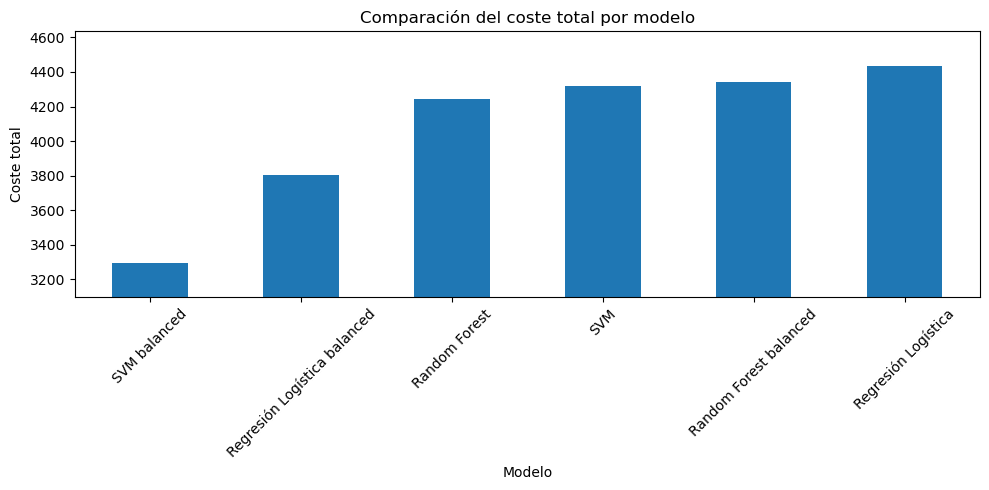

In [63]:
# Gráfico de barras para comparar costes
ax = df_costes.plot.bar(x="modelo", y="coste_total", legend=False, figsize=(10, 5), rot=45)

plt.title("Comparación del coste total por modelo")
plt.ylabel("Coste total")
plt.xlabel("Modelo")

# Ajuste dinámico de escala
plt.ylim(df_costes["coste_total"].min() - 200, df_costes["coste_total"].max() + 200)
plt.tight_layout()
plt.show()

## 16. Ajuste del umbral de decisión

En esta parte, comprobamos cual es el mejor umbral para el modelo de Regresión Logística con weight class

In [64]:
# Obtenemos la probabilidad de pertenecer a la clase positiva
y_proba = regresion_logistica_class.predict_proba(X_test)[:, 1]

# Definiendo umbrales
umbrales = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
resultados_umbrales = []

# Bucle para comprobar umbrales y guardarlos
for umbral in umbrales:
    y_pred_umbral = (y_proba >= umbral).astype(int)
    
    matriz = confusion_matrix(y_test, y_pred_umbral)
    tn, fp, fn, tp = matriz.ravel()
    
    coste_total = (fp * coste_fp) + (fn * coste_fn)
    
    resultados_umbrales.append({
        "umbral": umbral,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "coste_total": coste_total
    })

# Mostrando los umbrales en un DataFrame
df_umbrales = pd.DataFrame(resultados_umbrales)
df_umbrales.sort_values("coste_total")


,umbral,TN,FP,FN,TP,coste_total
4,0.6,7222,763,552,506,3523
5,0.7,7608,377,657,401,3662
3,0.5,6175,1810,399,659,3805
2,0.4,4405,3580,215,843,4655
1,0.3,2526,5459,91,967,5914
0,0.2,1179,6806,38,1020,6996


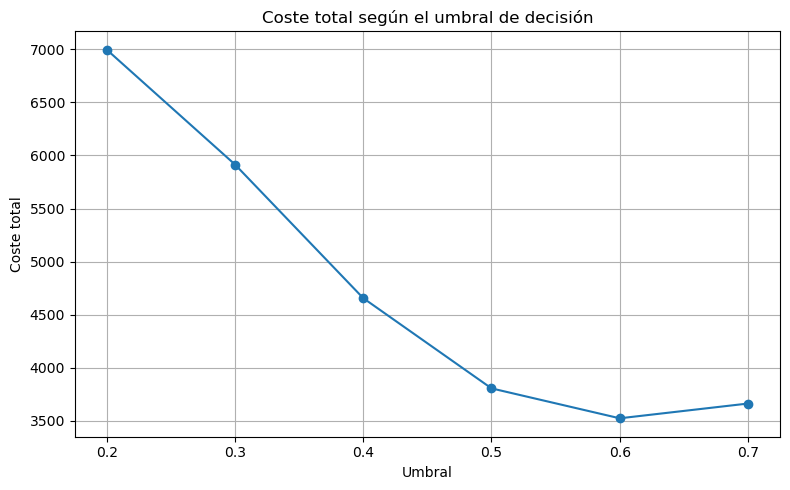

Exception ignored in: <function ResourceTracker.__del__ at 0x7dd38f78efc0>
Traceback (most recent call last):
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x72439ae86fc0>
Traceback (most recent call last):
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac

In [65]:
plt.figure(figsize=(8, 5))
plt.plot(df_umbrales["umbral"], df_umbrales["coste_total"], marker="o")
plt.title("Coste total según el umbral de decisión")
plt.xlabel("Umbral")
plt.ylabel("Coste total")
plt.grid(True)
plt.tight_layout()
plt.show()


## 17. Conclusión final del notebook

He comprobado que el accuracy no es suficiente para elegir el mejor modelo, ya que el dataset está desbalanceado. Al analizar los falsos positivos, falsos negativos y el coste total, el modelo más adecuado resulta ser SVM balanced. 

Aparte, el ajuste del umbral en Regresión Logística balanced demuestra que cambiar la regla de decisión puede reducir el coste total, aunque en este caso no supera al SVM balanced.